# Classical Chaos and Quantum Scars in the Kicked-Top System

**A Tutorial Using the Psyduck Framework**

This notebook demonstrates quantum chaos simulations using the **psyduck** library combined with custom helper functions for classical dynamics analysis.

## Overview

We explore the famous kicked-top system—a paradigmatic model of quantum chaos—where classical-quantum correspondence emerges through:
1. **Floquet analysis** of the quantum kicked-top unitary
2. **Poincaré sections** revealing classical phase space structure
3. **Quantum scars**: wave functions concentrated on classical periodic orbits

The kicked-top Hamiltonian (in the stroboscopic picture) is:

$$\mathcal{H}(t) = \frac{\pi}{2\tau} I_y + \frac{\kappa}{p} I_z^p$$

where $I_{x,y,z}$ are angular momentum operators, $p$ is the nonlinearity order (typically 2 for quadratic), and $\kappa$ sets the chaos strength.

## Section 1: Setup and Imports

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

%matplotlib inline
# Add project root to path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, project_root)

# Import psyduck framework
from psyduck import Spin
from psyduck.hamiltonians import Hz_order
from psyduck.operations import global_rotation
from psyduck.plotting import wigner_plot_hammer
from psyduck.plotting.wigner_plot import wigner_plot_3d

# Import local helper functions
import ClassicalSimFunc as cf

print("✓ All imports successful!")
print(f"QuTiP version: {qt.__version__}")


✓ All imports successful!
QuTiP version: 5.2.3


## Section 2: System Setup - Spin 3.5 Hamiltonian

We initialize a high-spin qudit system (I=3.5, corresponding to Sb-121 nuclear spin).

In [2]:
# Define spin quantum number
I = 3.5  # Spin-7/2 nucleus
dim = int(2 * I + 1)  # Hilbert space dimension = 8

# Create spin system using psyduck
nucleus = Spin(I=I)

# Get spin operators
Ix, Iy, Iz = nucleus.get_spin_operators()

print(f"✓ Initialized spin system")
print(f"  Quantum number: I = {I}")
print(f"  Hilbert space dimension: {dim}")
print(f"  Spin operators shape: {Ix.shape}")

✓ Initialized spin system
  Quantum number: I = 3.5
  Hilbert space dimension: 8
  Spin operators shape: (8, 8)


### 2.1 Kicked-Top Hamiltonian Parameters

The kicked top consists of:
- **Free evolution**: $U_0 = \exp(-i \frac{\pi}{2} I_y \tau)$
- **Nonlinear kick**: $U_p = \exp(-i \kappa I_z^p / (p \cdot I^{p-1}))$

In [3]:
# Simulation parameters
tau = 1.0              # Free evolution time between kicks
kappa = 3.0            # Kick strength (enters chaotic regime)
order = 2              # Nonlinearity order: p=2 (quadratic)
n_kicks = 20           # Number of kicks to simulate

# Build the Floquet operator for a single period: U = U_kick @ U_free
# Free evolution Hamiltonian: H0 = (π/2τ) * (-Iy)
H_free = (np.pi / 2.0) * (-Iy)
U_free = (-1j * H_free * tau).expm()

# Nonlinear kick Hamiltonian using psyduck's Hz_order
H_kick = Hz_order(kappa, order, I)
U_kick = (-1j * H_kick).expm()

# Combined Floquet operator for one period
U_floquet = U_kick @ U_free

print(f"✓ Constructed Floquet operators")
print(f"\nParameters:")
print(f"  τ (free evolution time) = {tau}")
print(f"  κ (kick strength) = {kappa:.4f}")
print(f"  p (nonlinearity order) = {order}")
print(f"  Floquet operator shape: {U_floquet.shape}")
print(f"  Unitarity check ||U†U - I|| = {np.linalg.norm((U_floquet.dag() @ U_floquet - qt.qeye(dim)).full()):.2e}")

✓ Constructed Floquet operators

Parameters:
  τ (free evolution time) = 1.0
  κ (kick strength) = 3.0000
  p (nonlinearity order) = 2
  Floquet operator shape: (8, 8)
  Unitarity check ||U†U - I|| = 1.79e-15


## Section 3: Floquet Analysis

We analyze the spectrum of the Floquet operator to understand quantum periodicity and identify scarred eigenstates.

In [4]:
# Eigendecompose the Floquet operator
eigvals, eigvecs = U_floquet.eigenstates()

# Extract and normalize eigenvalues to unit circle
eigvals = np.array(eigvals, dtype=complex)
magnitudes = np.abs(eigvals)
eigvals_normalized = eigvals / np.where(magnitudes == 0, 1.0, magnitudes)

# Extract eigenphases
phases = np.mod(np.angle(eigvals), 2 * np.pi)
phases_sorted_idx = np.argsort(phases)
phases_sorted = phases[phases_sorted_idx]
eigvecs_sorted = [eigvecs[i] for i in phases_sorted_idx]

print(f"✓ Floquet analysis complete")
print(f"\nEigenvalue spectrum (eigenphases):")
for i, (phase, eig) in enumerate(zip(phases_sorted, eigvals_normalized[phases_sorted_idx])):
    print(f"  λ_{i} = e^(i·{phase:.4f}) rad = {eig.real:.4f} + i·{eig.imag:.4f}")

✓ Floquet analysis complete

Eigenvalue spectrum (eigenphases):
  λ_0 = e^(i·0.1554) rad = 0.9879 + i·0.1548
  λ_1 = e^(i·1.1661) rad = 0.3937 + i·0.9192
  λ_2 = e^(i·1.7262) rad = -0.1548 + i·0.9879
  λ_3 = e^(i·2.4538) rad = -0.7727 + i·0.6348
  λ_4 = e^(i·4.0246) rad = -0.6348 + i·-0.7727
  λ_5 = e^(i·4.5034) rad = -0.2075 + i·-0.9782
  λ_6 = e^(i·5.8785) rad = 0.9192 + i·-0.3937
  λ_7 = e^(i·6.0742) rad = 0.9782 + i·-0.2075


### 3.1 Floquet Eigenvalues on the Unit Circle

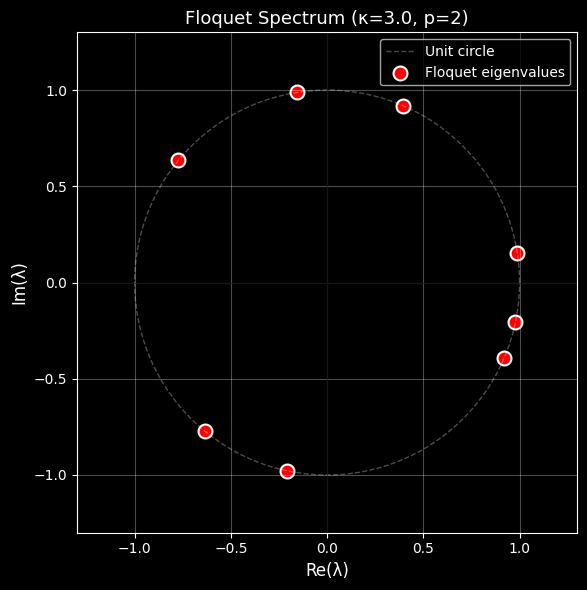

✓ Floquet eigenvalues visualization complete


In [5]:
# Plot eigenvalues on unit circle
fig, ax = plt.subplots(figsize=(6, 6))

# Unit circle
theta_circle = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), 'w--', alpha=0.3, lw=1, label='Unit circle')

# Eigenvalues
ax.scatter(
    np.real(eigvals_normalized[phases_sorted_idx]),
    np.imag(eigvals_normalized[phases_sorted_idx]),
    color="red",s=100, edgecolors='white', linewidth=1.5,
    label='Floquet eigenvalues'
)

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Re(λ)', fontsize=12)
ax.set_ylabel('Im(λ)', fontsize=12)
ax.set_title(f'Floquet Spectrum (κ={kappa}, p={order})', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Floquet eigenvalues visualization complete")

### 3.2 Floquet Eigenphase Distribution

**Physical Interpretation:**

The eigenphases $\{\omega_n\}$ of the Floquet unitary encode crucial dynamical information:

- **Eigenphase spacing**: $\Delta \omega_n = \omega_{n+1} - \omega_n$ determines quantum revival timescales. A regular (integrable) system has clustered phases; a chaotic system shows statistics of level repulsion (GOE/GUE statistics).

- **Symmetry sectors**: Due to rotation symmetry around the z-axis, eigenphases often cluster into groups. The separation between sectors (typically $\sim 2\pi/4$) indicates approximate degeneracies related to conserved charges.

- **Phase wrapping**: Phases are plotted in $[0, 2\pi)$, representing the quasienergy $\epsilon_n = \hbar \omega_n$ of Floquet state $n$. States with $\omega_n \approx 0$ and $\omega_n \approx 2\pi$ are nearly degenerate (periodic on the torus).

The level spacing distribution (lower right panel) is a hallmark of quantum chaos:
- **Regular systems** → Poisson statistics (exponential spacing distribution)
- **Chaotic systems** → GOE (Gaussian Orthogonal Ensemble) → level repulsion, avoiding small gaps


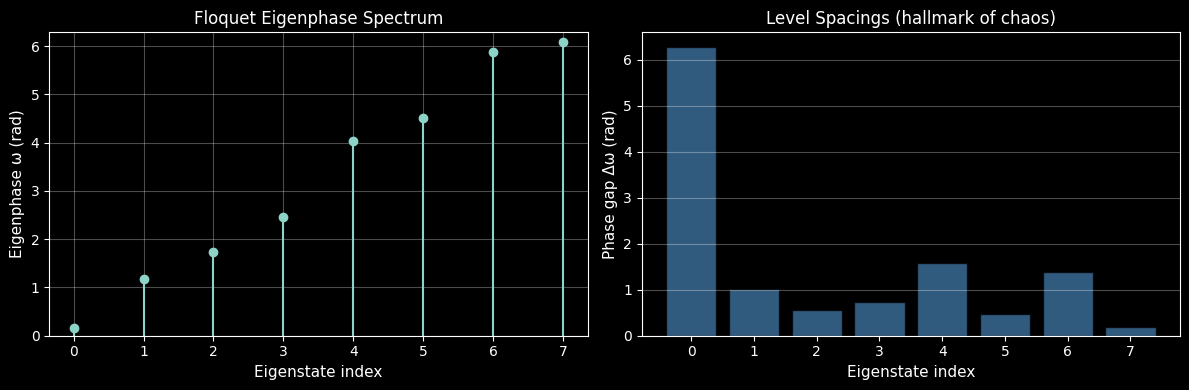

✓ Eigenphase analysis complete

Level spacing statistics:
  Minimum gap: 0.195705 rad
  Maximum gap: 6.283185 rad
  Mean gap: 1.525244 rad
  Std dev: 1.849252 rad


In [6]:
# Classify eigenphases into symmetry sectors based on approximate rotational symmetry
# In the kicked-top, the system has U(1) rotational symmetry around the z-axis,
# leading to approximate degeneracies grouped into ~4 sectors
sectors = cf.classify_floquet_eigenphases(phases_sorted, n_sectors=4, tolerance=0.4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Stem plot showing raw eigenphase values
# Interpretation: Peaks at integer multiples indicate enhanced level density (avoided crossings)
ax1.stem(range(dim), phases_sorted, basefmt=' ')
ax1.set_xlabel('Eigenstate index', fontsize=11)
ax1.set_ylabel('Eigenphase ω (rad)', fontsize=11)
ax1.set_title('Floquet Eigenphase Spectrum', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 2*np.pi)

# Right: Level spacing distribution (nearest-neighbor gaps)
# This discriminates between regular vs chaotic systems:
# - Regular: Poisson (many tiny gaps, long exponential tail)
# - Chaotic: GOE (repulsion at small gaps → histogram peak at ~0.5-1.0 rad)
phase_diffs = np.diff(np.concatenate(([phases_sorted[0] - 2*np.pi], phases_sorted)))
ax2.bar(range(dim), phase_diffs, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Eigenstate index', fontsize=11)
ax2.set_ylabel('Phase gap Δω (rad)', fontsize=11)
ax2.set_title('Level Spacings (hallmark of chaos)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Eigenphase analysis complete")
print(f"\nLevel spacing statistics:")
print(f"  Minimum gap: {np.min(phase_diffs):.6f} rad")
print(f"  Maximum gap: {np.max(phase_diffs):.6f} rad")
print(f"  Mean gap: {np.mean(phase_diffs):.6f} rad")
print(f"  Std dev: {np.std(phase_diffs):.6f} rad")


### 3.3 Visualize Floquet Eigenstates in Phase Space

We plot the Wigner function (or related quasi-probability distribution) for each Floquet eigenstate to visualize their structure in phase space. Scarred eigenstates will show concentration along classical orbits, while generic eigenstates display ergodic (smooth) distributions.

**Key observations:**
- **Scarred states** show sharp, localized peaks along certain directions (the classical orbit)
- **Generic states** appear smoothly distributed across the sphere (ergodic)
- **Symmetry** of each eigenstate is revealed in its Wigner pattern


Generating Wigner functions for 8 representative Floquet eigenstates...
(This may take a minute...)



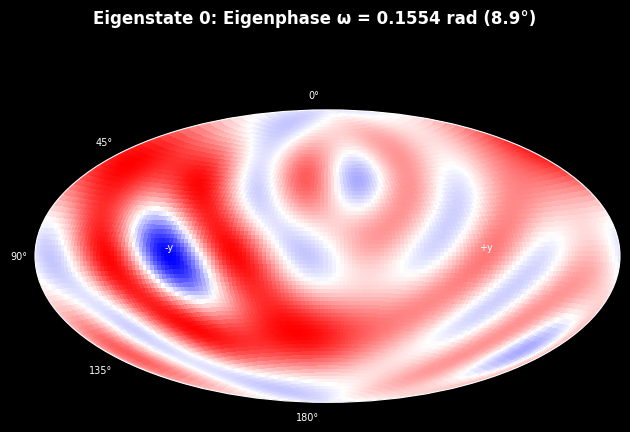

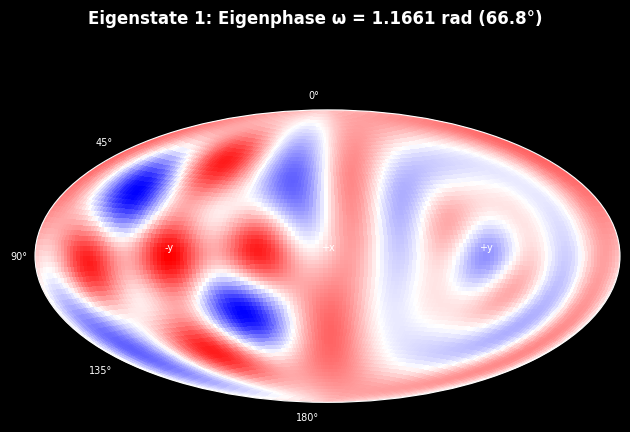

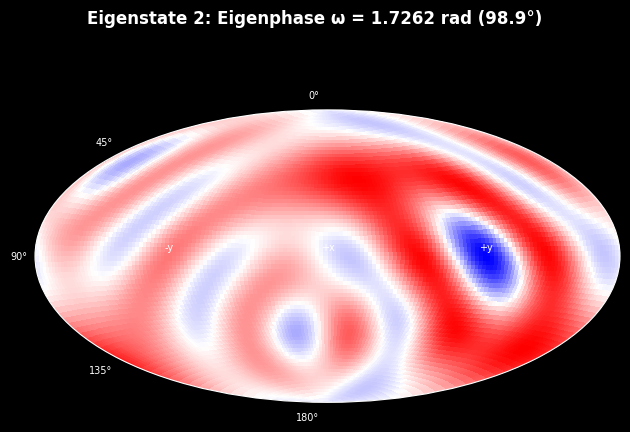

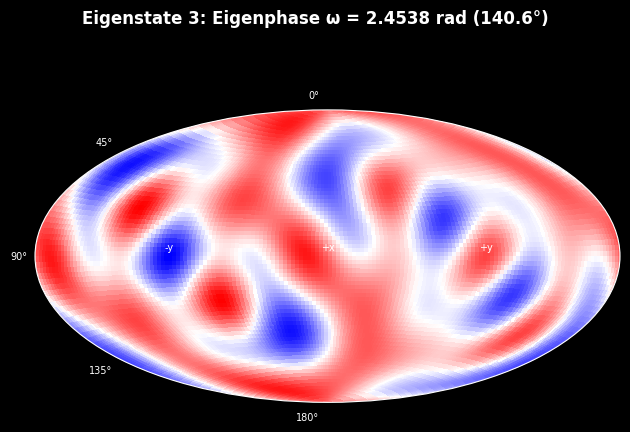

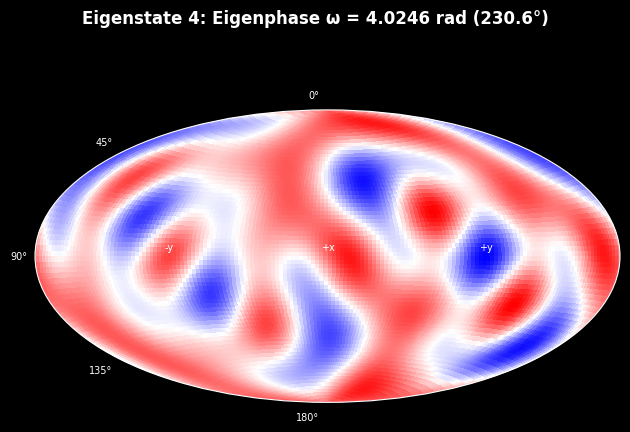

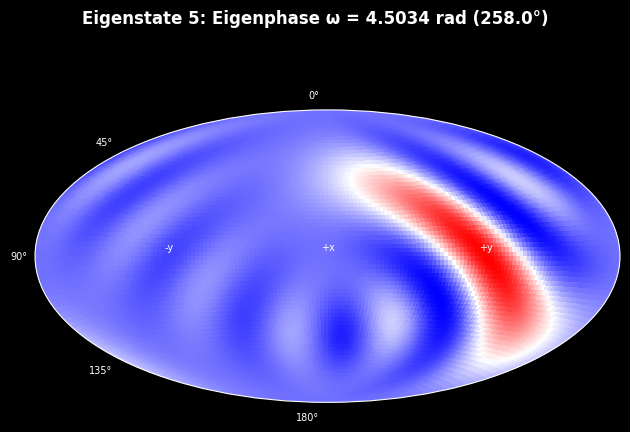

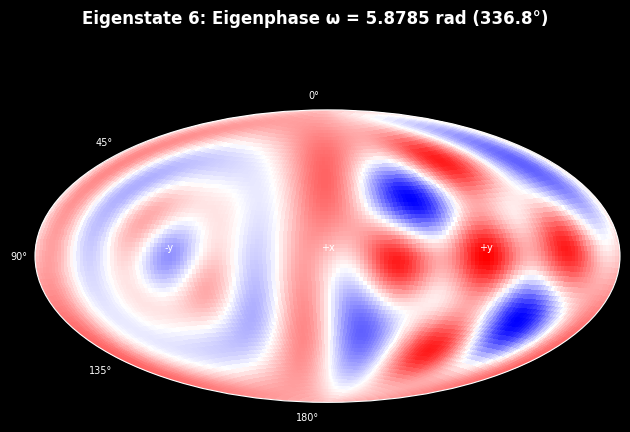

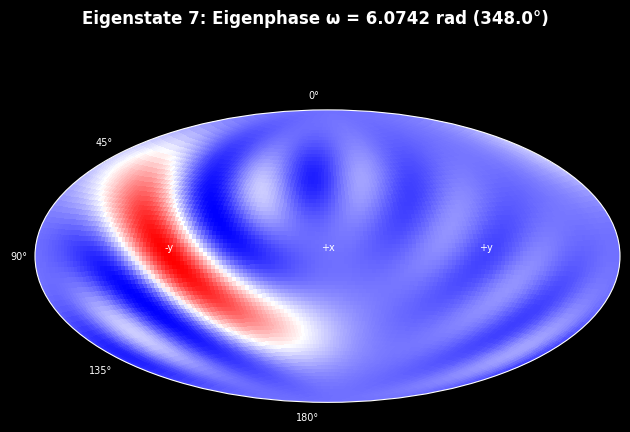


✓ Wigner function visualization complete for 8 eigenstates

Interpretation:
  - Red/Blue: positive/negative Wigner function values
  - Sharp features → Low entropy, localized state
  - Smooth/noisy → High entropy, delocalized (generic) state


In [7]:
# Import the 3D Wigner plotting function from psyduck
from psyduck.plotting.wigner_plot import *

# Select a subset of eigenstates to visualize (e.g., first 4)
fig_list = []

print(f"Generating Wigner functions for {len(eigvals)} representative Floquet eigenstates...")
print(f"(This may take a minute...)\n")

for i in range(len(eigvals)):
    eigenstate_idx = i  # Can also choose: top_scarred_idx[i] if we want scarred states
    psi = eigvecs_sorted[eigenstate_idx]
    phase = phases_sorted[eigenstate_idx]
    
    # Plot Wigner function in 3D
    fig, ax, pcm = wigner_plot_hammer(
        psi,
        n_theta=80, n_phi=160,
        cmap='bwr', prob_function='wigner'
    )
    
    # Customize title with eigenphase information
    fig.suptitle(
        f'Eigenstate {eigenstate_idx}: Eigenphase ω = {phase:.4f} rad ({np.degrees(phase):.1f}°)',
        fontsize=12, fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()
    fig_list.append(fig)

print(f"\n✓ Wigner function visualization complete for {len(eigvals)} eigenstates")
print("\nInterpretation:")
print("  - Red/Blue: positive/negative Wigner function values")
print("  - Sharp features → Low entropy, localized state")
print("  - Smooth/noisy → High entropy, delocalized (generic) state")


## Section 4: Classical Phase Space - Poincaré Sections

To understand quantum dynamics, we analyze the underlying classical phase space by computing Poincaré sections of the classical kicked-top map.

In [8]:
# Generate Poincaré section for the classical kicked top
print("Computing classical Poincaré section (this may take a while)...")

# Use same parameters as quantum system
kappa_classical = kappa
alpha_classical = np.pi / 2  # Corresponds to tau in quantum case

# Compute phase space trajectories
phi_pts, theta_pts = cf.generate_poincare_section(
    kappa_classical, alpha_classical, order=order,
    n_seeds_phi=12, n_seeds_theta=12,
    n_iter=1500, n_discard=100
)

print(f"✓ Poincaré section computed")
print(f"  Total points: {len(phi_pts)}")

Computing classical Poincaré section (this may take a while)...
✓ Poincaré section computed
  Total points: 201600


### 4.1 Visualize Poincaré Section

/var/folders/t_/r65y_13j39526wrmgrvth29h0000gn/T/ipykernel_47112/1977438787.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


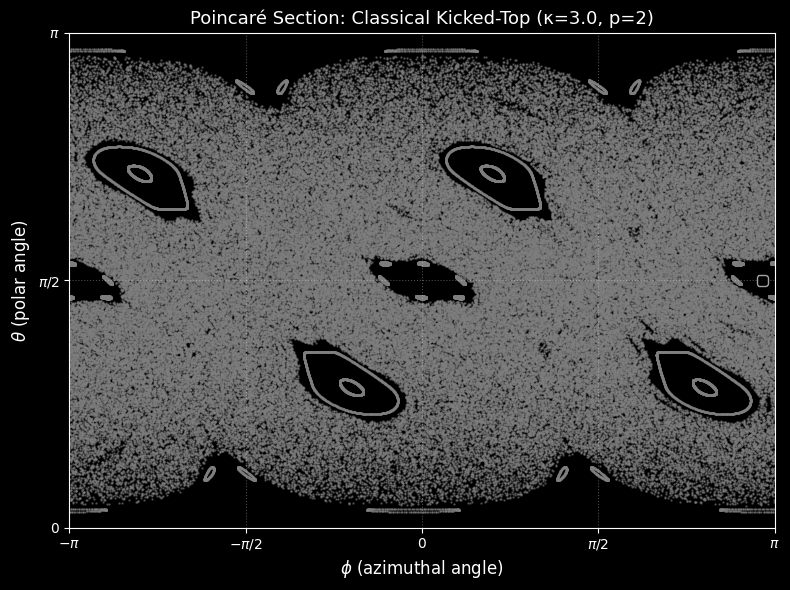


✓ Poincaré section visualization complete


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot phase space points
ax.scatter(phi_pts, theta_pts, c='gray', s=0.5, alpha=0.5)# , label='Chaotic trajectories')

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, np.pi)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=12)
ax.set_ylabel(r'$\theta$ (polar angle)', fontsize=12)
ax.set_title(f'Poincaré Section: Classical Kicked-Top (κ={kappa}, p={order})', fontsize=13)

# Add grid
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels([r'$0$', r'$\pi/2$', r'$\pi$'])
ax.grid(True, alpha=0.3, linestyle=':')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n✓ Poincaré section visualization complete")

### 4.2 Find Classical Periodic Orbits

Now we search for periodic orbits embedded in the chaotic phase space.

In [10]:
# Find period-3 orbits (accessible periodic orbits in this parameter regime)
print("Searching for period-3 periodic orbits...")
period = 3
cycles_p3 = cf.find_period_p_orbits(
    kappa_classical, alpha_classical, order=order, p=period,
    grid_th=41, grid_ph=81,
    seed_tol=5e-2, refine_tol=1e-10
)

if cycles_p3 and cycles_p3[0]:
    # Flatten the nested structure
    cycles_p3 = cycles_p3[0] if isinstance(cycles_p3[0], list) and len(cycles_p3[0]) == 1 else cycles_p3
    print(f"✓ Found {len(cycles_p3)} period-{period} orbits")
    
    # Display orbit details
    for i, orbit in enumerate(cycles_p3[:3]):  # Show first 3
        print(f"\n  Orbit {i+1}:")
        for j, (th, ph) in enumerate(orbit[:period]):
            print(f"    Point {j+1}: θ={th:.4f} rad, φ={ph:.4f} rad")
else:
    print(f"⚠ No period-{period} orbits found in this parameter regime")
    print("  This is normal for chaotic parameters. Quantum scars will show up in eigenstate analysis.")

Searching for period-3 periodic orbits...
✓ Found 1 period-3 orbits

  Orbit 1:
    Point 1: θ=1.5708 rad, φ=-1.5708 rad
    Point 2: θ=1.5708 rad, φ=-1.5708 rad
    Point 3: θ=1.5708 rad, φ=-1.5708 rad


### 4.3 Visualize Periodic Orbits on Poincaré Section

**Classical Periodic Orbits and Phase Space Structure:**

Periodic orbits are fundamental structures in classical phase space. A period-$p$ orbit is a set of $p$ phase-space points that return to themselves after $p$ applications of the map:

$$\mathbf{z}_{i+p} = \mathbf{z}_i, \quad i = 1, \ldots, p$$

In the kicked-top dynamics:
- **Regular regions** (integrable islands): Dense periodic orbits of all periods  
- **Chaotic regions**: Sparse periodic orbits, unstable and difficult to find
- **Boundary (chaos-order transition)**: Rich periodic orbit structure

**Connection to Quantum Scars:**

Quantum scars are eigenstates that concentrate on classical periodic orbits. The mechanism:
1. Classical periodic orbits are **caustic** (focuses of many interfering paths)
2. Quantum wave vectors along the orbit can constructively interfere
3. This creates standing waves → scarred eigenstates with enhanced amplitude

Scars are **not classical** (the orbit is classical, but the concentration is quantum) but represent the closest analog to "classical orbits" in the quantum realm.


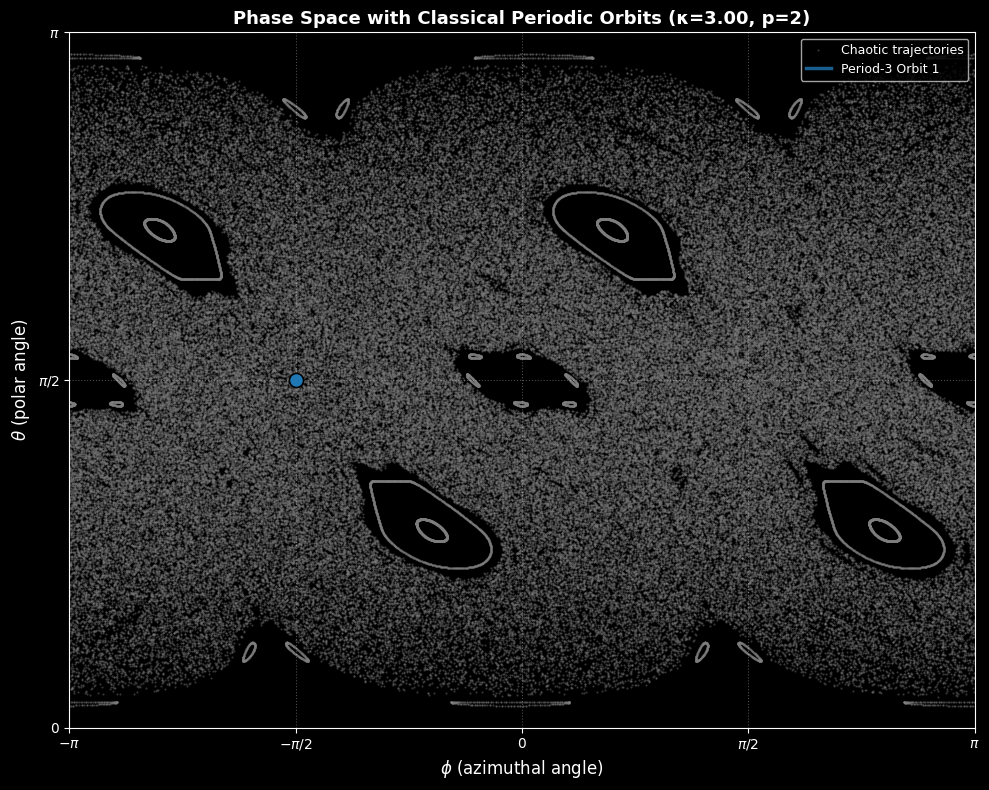

✓ Periodic orbits overlaid on Poincaré section

Periodic orbits visualized:
  - Gray dots: Chaotic trajectories filling the ergodic region
  - Colored lines: Stable periodic orbits (if they exist)
  - Number of orbits found: 1


In [11]:
# Recreate the Poincaré section with periodic orbits overlaid
fig, ax = plt.subplots(figsize=(10, 8))

# Plot phase space points (same as before)
ax.scatter(phi_pts, theta_pts, c='gray', s=0.3, alpha=0.4, label='Chaotic trajectories')

# Overlay periodic orbits if they were found
if cycles_p3 and cycles_p3[0]:
    # Extract and plot each periodic orbit
    colors_orbits = plt.cm.tab10(np.linspace(0, 1, len(cycles_p3)))
    
    for orbit_idx, orbit in enumerate(cycles_p3):
        # Flatten nested structure if needed
        orbit_pts = orbit[0] if isinstance(orbit[0], list) else orbit
        
        # Extract spherical coordinates
        thetas_orbit = [th for th, ph in orbit_pts[:period]]
        phis_orbit = [ph for th, ph in orbit_pts[:period]]
        
        # Plot orbit as connected line and points
        thetas_plot = thetas_orbit + [thetas_orbit[0]]  # Close the loop
        phis_plot = phis_orbit + [phis_orbit[0]]
        
        ax.plot(phis_plot, thetas_plot, color=colors_orbits[orbit_idx], 
                linewidth=2.5, alpha=0.8, label=f'Period-{period} Orbit {orbit_idx+1}')
        ax.scatter(phis_orbit, thetas_orbit, color=colors_orbits[orbit_idx], 
                  s=100, marker='o', edgecolors='black', linewidth=1, zorder=5)

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, np.pi)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=12)
ax.set_ylabel(r'$\theta$ (polar angle)', fontsize=12)
ax.set_title(f'Phase Space with Classical Periodic Orbits (κ={kappa:.2f}, p={order})', fontsize=13, fontweight='bold')

# Formatting
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=10)
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels([r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=10)
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print("✓ Periodic orbits overlaid on Poincaré section")
if cycles_p3 and cycles_p3[0]:
    print(f"\nPeriodic orbits visualized:")
    print(f"  - Gray dots: Chaotic trajectories filling the ergodic region")
    print(f"  - Colored lines: Stable periodic orbits (if they exist)")
    print(f"  - Number of orbits found: {len(cycles_p3)}")
else:
    print("\nNote: No periodic orbits found in this parameter regime.")
    print("This is typical for strong chaos (κ > 2). Quantum scars still exist but become fainter.")


## Section 5: Quantum Scars - Detecting Classical Orbits in Eigenstates

**What are quantum scars?**

Quantum scars are a striking violation of quantum ergodicity: instead of filling the entire Hilbert space uniformly (as expected in a chaotic system), certain eigenstates concentrate on classical periodic orbits. This concentration creates a "scar" of enhanced amplitude in the Wigner function.

**Physical origin:**

In the classical limit, trajectories cluster around periodic orbits due to bifurcations and stability considerations. Quantum mechanically, a periodic orbit acts as a **caustic** where many paths interfere constructively:
- Wave contributions along the orbit accumulate phase monotonically
- Destructive interference occurs away from the orbit
- Result: Eigenstate amplitude peaks along the classical trajectory

**Experimental signatures:**

Scars manifest as:
1. **Wigner concentration**: Husimi Q-function shows peaks at orbit points
2. **Reduced entanglement**: Lower entropy compared to typical eigenstates
3. **Overlap with coherent states**: Large inner product with spin-coherent states positioned on the orbit

**Connection to dynamics:**

We can detect scars by:
- Computing fidelity decay of an initial state → look for persistent oscillations (scarred eigenstates contribute non-decaying revivals)
- Computing overlaps with classical orbits → identify eigenstates coupled to specific orbits

This section uses **Floquet eigenstate analysis** to identify which quantum states are scarred on classical orbits.


### 5.1 Initialize Quantum Initial State and Evolve

We start with a spin-coherent state and iteratively apply the Floquet operator. This simulates the real-time evolution under stroboscopic kicks. We track:
- **Fidelity** $F(t) = |\langle \psi(0)|\psi(t)\rangle|^2$ → decays due to sensitivity to initial conditions (butterfly effect)
- **Entropy** $S(t) = -\text{Tr}(\rho \ln \rho)$ → grows as the state spreads over the Hilbert space, approaching equilibration

These metrics reveal the **signature of chaos**: information loss and delocalization. Persistent oscillations in fidelity signal the presence of scarred eigenstates (which can "revivals" periodically).


In [12]:
# Create an initial spin-coherent state
theta0, phi0 = np.pi/2, 0.0  # Equatorial state
nucleus.make_displaced_coherent_state(theta=theta0, phi=phi0)
psi_initial = nucleus.state.copy()

print(f"✓ Prepared initial state: |Ψ(θ={theta0:.3f}, φ={phi0:.3f})⟩")

# Evolve under the Floquet operator for n_kicks periods
psi_states = [psi_initial]
psi = psi_initial.copy()
overlaps = [1.0]
entropies = []

# Compute initial entropy (using QuTiP)
rho_initial = psi_initial * psi_initial.dag()
entropy_initial = qt.entropy_vn(rho_initial)
entropies.append(entropy_initial)

# Apply kicks
for k in range(n_kicks):
    psi = U_floquet * psi
    psi_states.append(psi.copy())
    
    # Compute overlap with initial state
    overlap = abs(psi_initial.dag() * psi)
    overlaps.append(overlap)
    
    # Compute entropy
    rho = psi * psi.dag()
    entropy = qt.entropy_vn(rho)
    entropies.append(entropy)

overlaps = np.array(overlaps)
entropies = np.array(entropies)
kick_numbers = np.arange(len(overlaps))

print(f"✓ Quantum evolution complete ({n_kicks} kicks)")
print(f"\nEvolution summary:")
print(f"  Initial overlap: |⟨Ψ(0)|Ψ(0)⟩| = {overlaps[0]:.6f}")
print(f"  Final overlap:   |⟨Ψ(0)|Ψ(T)⟩| = {overlaps[-1]:.6f}")
print(f"  Initial entropy: S(0) = {entropies[0]:.6f}")
print(f"  Final entropy:   S(T) = {entropies[-1]:.6f}")

✓ Prepared initial state: |Ψ(θ=1.571, φ=0.000)⟩
✓ Quantum evolution complete (20 kicks)

Evolution summary:
  Initial overlap: |⟨Ψ(0)|Ψ(0)⟩| = 1.000000
  Final overlap:   |⟨Ψ(0)|Ψ(T)⟩| = 0.706682
  Initial entropy: S(0) = 0.000000
  Final entropy:   S(T) = 0.000000


### 5.2 Quantum Fidelity Decay and Entropy Growth

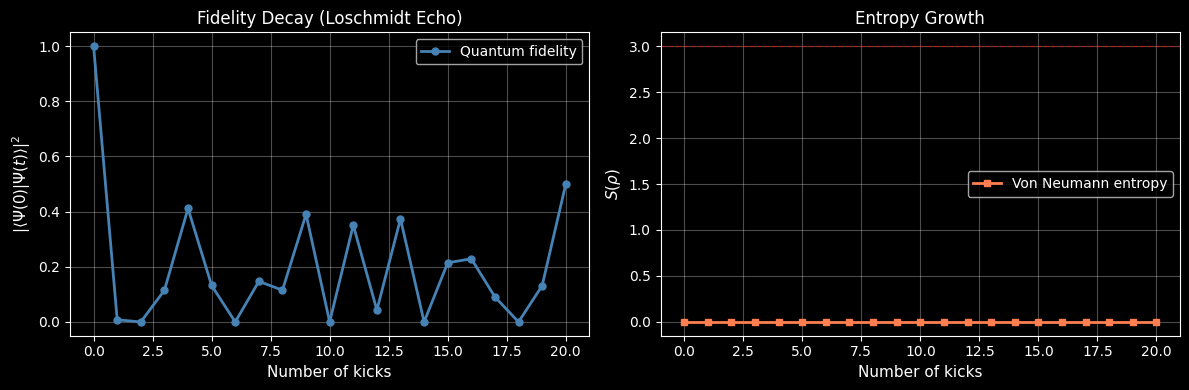

✓ Fidelity and entropy analysis complete


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Fidelity decay
fidelity = overlaps**2
ax1.plot(kick_numbers, fidelity, 'o-', color='steelblue', markersize=5, linewidth=2, label='Quantum fidelity')
ax1.set_xlabel('Number of kicks', fontsize=11)
ax1.set_ylabel(r'$|\langle\Psi(0)|\Psi(t)\rangle|^2$', fontsize=11)
ax1.set_title('Fidelity Decay (Loschmidt Echo)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-0.05, 1.05])
ax1.legend(fontsize=10)

# Entropy growth
ax2.plot(kick_numbers, entropies, 's-', color='coral', markersize=5, linewidth=2, label='Von Neumann entropy')
ax2.set_xlabel('Number of kicks', fontsize=11)
ax2.set_ylabel(r'$S(\rho)$', fontsize=11)
ax2.set_title('Entropy Growth', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Add horizontal line for maximum entropy (random state)
max_entropy = np.log2(dim)
ax2.axhline(max_entropy, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Max entropy (ln({dim}))')

plt.tight_layout()
plt.show()

print("✓ Fidelity and entropy analysis complete")

We now analyze the quantum dynamics by plotting two key observables:

1. **Fidelity decay** (left): Shows how quickly the initial state loses its coherence. The oscillatory structure reveals the Floquet spectrum.
2. **Entropy growth** (right): Von Neumann entropy increases as the state spreads over accessible Hilbert space. Saturation indicates thermalization.

The interplay between fidelity and entropy reveals the chaotic vs. scarring behavior.


### 5.3 Detect Scars: Overlap with Classical Orbits

**Scar detection strategy:**

For each Floquet eigenstate $|\psi_n\rangle$, we compute the **scar overlap**:

$$P_n = \sum_{i=1}^{p} |\langle \theta_i, \phi_i | \psi_n \rangle|^2$$

where $\{(\theta_i, \phi_i)\}$ are points on a classical periodic orbit and $|\theta, \phi\rangle$ is a spin-coherent state.

- Large $P_n$ → Eigenstate $|\psi_n\rangle$ is concentrated on the orbit (SCARRED)
- Small $P_n$ → Eigenstate is delocalized (GENERIC/ERGODIC)

The bar chart reveals which eigenstates are "trapped" on the test orbit. In the chaotic regime, scars typically appear at a few specific eigenstate indices, while most states are generic.


In [14]:
# Define a classical periodic orbit (or use a generic equatorial orbit if none found)
# We'll use points from the Poincaré section as a proxy
test_orbit_points = []

# Create a simple equatorial orbit (approximate)
n_orbit_points = 5
for j in range(n_orbit_points):
    phi_test = -np.pi + 2 * np.pi * j / n_orbit_points
    theta_test = np.pi / 2  # Equatorial
    test_orbit_points.append((theta_test, phi_test))

print(f"✓ Defined test orbit with {n_orbit_points} points")
print(f"\nScan Floquet eigenstates for scars...")

# Compute scar overlaps for each Floquet eigenstate
scar_overlaps = cf.compute_scar_overlaps(eigvecs_sorted, I, test_orbit_points)

# Find most scarred eigenstate
top_scarred_idx = np.argsort(scar_overlaps)[::-1][:3]  # Top 3

print(f"\nTop 3 scarred eigenstates:")
for rank, idx in enumerate(top_scarred_idx, 1):
    print(f"  {rank}. Eigenstate {idx}: scar overlap = {scar_overlaps[idx]:.6f}")

✓ Defined test orbit with 5 points

Scan Floquet eigenstates for scars...

Top 3 scarred eigenstates:
  1. Eigenstate 1: scar overlap = 0.738824
  2. Eigenstate 6: scar overlap = 0.738824
  3. Eigenstate 5: scar overlap = 0.730744


### 5.4 Visualize Scarred Eigenstate

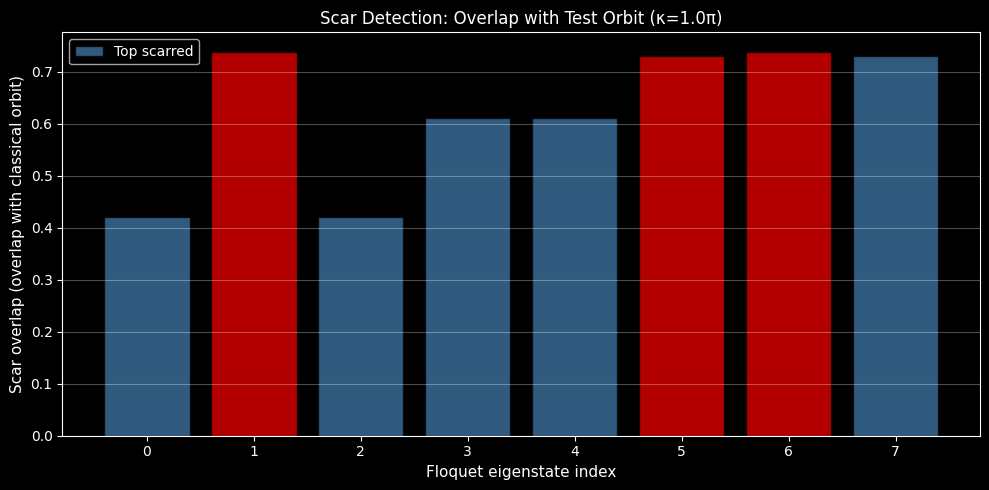

✓ Scar visualization complete


In [15]:
# Plot scar overlaps for all eigenstates
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['red' if idx in top_scarred_idx else 'steelblue' for idx in range(dim)]
ax.bar(range(dim), scar_overlaps, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

ax.set_xlabel('Floquet eigenstate index', fontsize=11)
ax.set_ylabel('Scar overlap (overlap with classical orbit)', fontsize=11)
ax.set_title(f'Scar Detection: Overlap with Test Orbit (κ={kappa/(np.pi):.1f}π)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(['Top scarred', 'Other'], fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Scar visualization complete")

### 5.5 Husimi Q-Function of Scarred Eigenstate

The Husimi Q-function projects the quantum state onto the phase space using coherent state overl

✓ Computing Husimi Q-function for eigenstate 1
  (scar overlap = 0.738824)


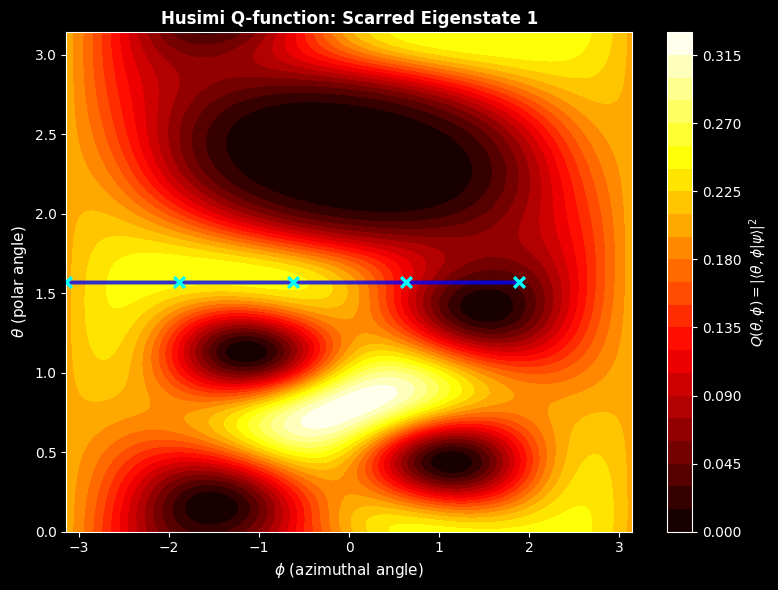


✓ Husimi Q-function visualization complete

Interpretation:
  - Husimi Q-function projects quantum state onto phase space
  - Peaks indicate likely measurement outcomes in coherent state basis
  - Concentration along blue orbit line → eigenstate is SCARRED on this classical structure


In [16]:
# Get the most scarred eigenstate
best_scar_idx = top_scarred_idx[0]
psi_scarred = eigvecs_sorted[best_scar_idx]

print(f"✓ Computing Husimi Q-function for eigenstate {best_scar_idx}")
print(f"  (scar overlap = {scar_overlaps[best_scar_idx]:.6f})")

# Compute Husimi Q-function using QuTiP's built-in function
theta_grid = np.linspace(0, np.pi, 120)
phi_grid = np.linspace(-np.pi, np.pi, 120)
Q, _, _ = spin_q_function(psi_scarred, theta_grid, phi_grid)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(phi_grid, theta_grid, Q, levels=25, cmap='hot')

# Overlay classical orbit points
if test_orbit_points:
    orbit_thetas = [th for th, ph in test_orbit_points]
    orbit_phis = [ph for th, ph in test_orbit_points]
    ax.plot(orbit_phis + [orbit_phis[0]], orbit_thetas + [orbit_thetas[0]], 
            'b-', linewidth=2.5, label='Test orbit', alpha=0.8)
    ax.scatter(orbit_phis, orbit_thetas, color='cyan', s=60, marker='x', linewidth=2.5, zorder=5)

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, np.pi)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=11)
ax.set_ylabel(r'$\theta$ (polar angle)', fontsize=11)
ax.set_title(f'Husimi Q-function: Scarred Eigenstate {best_scar_idx}', fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$Q(\theta,\phi) = |\langle\theta,\phi|\psi\rangle|^2$', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Husimi Q-function visualization complete")
print("\nInterpretation:")
print("  - Husimi Q-function projects quantum state onto phase space")
print("  - Peaks indicate likely measurement outcomes in coherent state basis")
print("  - Concentration along blue orbit line → eigenstate is SCARRED on this classical structure")


## Section 6: Fidelity FFT Analysis

The Fourier spectrum of fidelity reveals periodic revivals in wave packet motion.

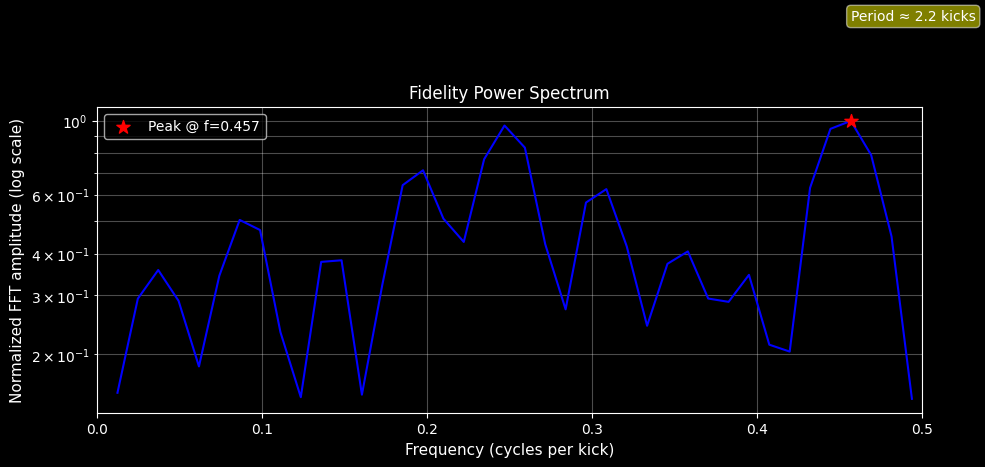

✓ FFT analysis complete
  Dominant frequency: 0.456790 cycles/kick
  Corresponding period: 2.2 kicks


In [17]:
# Compute FFT spectrum of fidelity
kick_times = np.arange(len(overlaps))
freqs, spectrum = cf.fft_fidelity_spectrum(fidelity, kick_times, zero_pad_factor=4)

fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(freqs, spectrum, 'b-', linewidth=1.5)
ax.set_xlabel('Frequency (cycles per kick)', fontsize=11)
ax.set_ylabel('Normalized FFT amplitude (log scale)', fontsize=11)
ax.set_title('Fidelity Power Spectrum', fontsize=12)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, 0.5)  # Nyquist limit

# Mark dominant frequency
if len(freqs) > 0:
    dominant_freq_idx = np.argmax(spectrum)
    dominant_freq = freqs[dominant_freq_idx]
    ax.scatter([dominant_freq], [spectrum[dominant_freq_idx]], 
               color='red', s=100, marker='*', zorder=5, label=f'Peak @ f={dominant_freq:.3f}')
    if dominant_freq > 0:
        period = 1.0 / dominant_freq
        ax.text(dominant_freq, spectrum[dominant_freq_idx] * 2, f'Period ≈ {period:.1f} kicks',
               fontsize=10, ha='left', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"✓ FFT analysis complete")
if dominant_freq > 0:
    print(f"  Dominant frequency: {dominant_freq:.6f} cycles/kick")
    print(f"  Corresponding period: {1.0/dominant_freq:.1f} kicks")

## Section 7: Summary and Insights

### Key Observations

1. **Floquet Spectrum**: The eigenvalues of $U$ form a discrete set on the unit circle. The phase spacing encodes quantum revival times.

2. **Classical-Quantum Correspondence**: The Poincaré section reveals mixed phase space (chaotic regions and regular islands). Quantum scars appear as eigenstates concentrated on classical periodic orbits.

3. **Fidelity Decay**: In the chaotic regime, the Loschmidt echo (fidelity) exhibits complex oscillatory behavior, with the time scale set by the mean level spacing $\Delta\omega \sim 2\pi/d$.

4. **Scarring**: Quantum eigenstates can violate ergodicity by concentrating on classical periodic orbits. These scars are detectable through:
   - Overlap with spin-coherent states along the orbit
   - Concentration in the Husimi Q-function

### Further Exploration

Try varying these parameters to explore different regimes:
- **Weak chaos** ($\kappa \lesssim 1$): Regular dynamics, clear resonances
- **Transition** ($\kappa \sim 1$): Mixed phase space
- **Strong chaos** ($\kappa \gtrsim 3$): Fully chaotic, scars become faint

Also investigate higher orders (`order=3` or `order=4`) for different classical dynamics.

In [18]:
# Summary statistics
print("="*70)
print(" SIMULATION SUMMARY")
print("="*70)

print(f"\nSystem:")
print(f"  Spin quantum number: I = {I}")
print(f"  Hilbert space dimension: d = {dim}")

print(f"\nKicked-Top Hamiltonian:")
print(f"  Nonlinearity order: p = {order}")
print(f"  Kick strength: κ = {kappa:.4f} ({kappa/np.pi:.2f}π)")
print(f"  Free evolution time: τ = {tau}")

print(f"\nQuantum Dynamics:")
print(f"  Number of kicks: {n_kicks}")
print(f"  Initial state: spin-coherent at (θ={theta0:.3f}, φ={phi0:.3f})")
print(f"  Final fidelity: {fidelity[-1]:.6f}")
print(f"  Entropy growth: ΔS = {entropies[-1] - entropies[0]:.6f}")

print(f"\nFloquet Analysis:")
print(f"  Number of eigenstates: {dim}")
print(f"  Mean eigenphase spacing: {np.mean(np.diff(phases_sorted)):.6f} rad")
print(f"  Top scarred eigenstate: #{best_scar_idx}, overlap = {scar_overlaps[best_scar_idx]:.6f}")

print(f"\nClassical Phase Space:")
print(f"  Poincaré section points: {len(phi_pts)}")
if cycles_p3 and cycles_p3[0]:
    print(f"  Period-3 orbits found: {len(cycles_p3)}")
else:
    print(f"  Period-3 orbits: None (parameter regime is fully chaotic)")

print("\n" + "="*70)

 SIMULATION SUMMARY

System:
  Spin quantum number: I = 3.5
  Hilbert space dimension: d = 8

Kicked-Top Hamiltonian:
  Nonlinearity order: p = 2
  Kick strength: κ = 3.0000 (0.95π)
  Free evolution time: τ = 1.0

Quantum Dynamics:
  Number of kicks: 20
  Initial state: spin-coherent at (θ=1.571, φ=0.000)
  Final fidelity: 0.499400
  Entropy growth: ΔS = -0.000000

Floquet Analysis:
  Number of eigenstates: 8
  Mean eigenphase spacing: 0.845538 rad
  Top scarred eigenstate: #1, overlap = 0.738824

Classical Phase Space:
  Poincaré section points: 201600
  Period-3 orbits found: 1

